import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

excel_file = pd.ExcelFile("Exchanges.xlsx")
excel_file.sheet_names

# Исследование глобальных бирж

## Цель исследования

Провести сравнительный анализ традиционных и криптовалютных бирж на основе выбранных показателей и сформировать итоговый рейтинг.

Исследование включает:
- сбор исходных данных;
- проверку и сопоставление показателей;
- нормализацию данных;
- применение весов критериев;
- расчет итоговой оценки;
- формирование рейтинга и Top-5. 

## 1. Исходные данные

Исходные данные для исследования собраны в файле `Exchanges.xlsx`.

Данные разделены на три листа:
- `Exchange Overview` — общая информация о рассматриваемых биржах;
- `Traditional Exchanges Evaluation` — показатели традиционных бирж;
- `Crypto Exchanges Evaluation` — показатели криптовалютных бирж.

Источники данных указаны в исходной таблице и рабочих материалах исследования.

In [3]:
overview = pd.read_excel(
    "Exchanges.xlsx",
    sheet_name="Exchange Overview"
)

traditional = pd.read_excel(
    "Exchanges.xlsx",
    sheet_name="Traditional Exchanges Evaluatio"
)

crypto = pd.read_excel(
    "Exchanges.xlsx",
    sheet_name="Crypto Exchanges Evaluation"
)

In [4]:
print("Exchange Overview:", overview.shape)
print("Traditional Exchanges:", traditional.shape)
print("Crypto Exchanges:", crypto.shape)

Exchange Overview: (29, 8)
Traditional Exchanges: (13, 7)
Crypto Exchanges: (16, 8)


## 2. Проверка структуры данных

Перед проведением анализа проверим набор показателей и качество исходных данных.

In [5]:
print("Показатели традиционных бирж:")
print(traditional.columns.tolist())

print("\nПоказатели криптовалютных бирж:")
print(crypto.columns.tolist())

Показатели традиционных бирж:
['Exchange name', 'YTD Trading Volume', 'Volume Unit', 'YTD Volume Change', 'Trading Fee', 'Trust Score', 'Number of Trading Instruments']

Показатели криптовалютных бирж:
['Exchange name', 'Total Trading Volume (USD)', 'Volume Unit', 'Trust Score', 'Average Bid-Ask Spread (%)', 'Base Maker Fee (%)', 'Base Taker Fee (%)', 'Number of Trading Instruments']


## 3. Анализ традиционных бирж

Для сравнительной оценки традиционных бирж используются следующие показатели:

- **YTD Trading Volume** — объем торгов с начала года;
- **YTD Volume Change** — изменение объема торгов с начала года;
- **Trading Fee** — торговые комиссии;
- **Trust Score** — экспертная оценка надежности;
- **Number of Trading Instruments** — количество доступных торговых инструментов.

Показатели имеют разные единицы измерения, поэтому перед расчетом итоговой оценки они приводятся к сопоставимой шкале.

In [6]:
traditional

,Exchange name,YTD Trading Volume,Volume Unit,YTD Volume Change,Trading Fee,Trust Score,Number of Trading Instruments
0,Chicago Mercantile Exchange (CME),2279477176,Contracts,11.5,"Комиссия за контракт; зависит от продукта, тип...",10,Тысячи фьючерсных и опционных контрактов по пр...
1,National Stock Exchange of India (NSE),24572357082,Contracts,25.2,Транзакционная комиссия зависит от сегмента ры...,9,"Более 2 000 акций, а также индексные, валютные..."
2,B3,7171823642,Contracts,18.6,"Комиссия зависит от рынка, инструмента и катег...",9,"Более 2 000 листинговых инструментов; акции, E..."
3,Korea Exchange (KRX),2175659647,Contracts,38.2,"Комиссия зависит от рынка, продукта и типа сделки",9,Более 2 600 листинговых компаний и широкий наб...
4,Dalian Commodity Exchange (DCE),2020111554,Contracts,34.0,Комиссия устанавливается по каждому фьючерсном...,8,Более 20 основных семейств товарных фьючерсов ...
5,Borsa Istanbul (BIST),2877712880,Contracts,77.7,Комиссия зависит от рынка; для срочного рынка ...,8,"Акции, долговые инструменты, драгоценные метал..."
6,ICE Futures Europe,1653950171,Contracts,26.9,Комиссия за контракт/лот; ставка зависит от ко...,10,Сотни фьючерсных и опционных продуктов по энер...
7,Eurex,1386551141,Contracts,8.8,"Комиссия за контракт; зависит от продукта, спо...",10,Более 2 000 продуктов
8,Multi Commodity Exchange of India,2090541130,Contracts,211.9,Транзакционная комиссия зависит от конкретного...,9,Десятки товарных фьючерсов и опционов: металлы...
9,Zhengzhou Commodity Exchange,2077089784,Contracts,16.3,Комиссия устанавливается отдельно для каждого ...,8,Более 30 основных семейств фьючерсов и опционов


### 3.2 Методология оценки

Для формирования рейтинга показатели приводятся к единой шкале от 0 до 1.

Для показателей, где большее значение является преимуществом, используется прямая нормализация:
- объем торгов;
- изменение объема торгов;
- количество торговых инструментов;
- Trust Score.

Для торговых комиссий используется обратная нормализация: чем ниже комиссия, тем выше оценка.

После нормализации каждому показателю присваивается вес, отражающий его значимость в итоговой оценке.

In [7]:
traditional_clean = traditional.copy()

traditional_clean.head()

,Exchange name,YTD Trading Volume,Volume Unit,YTD Volume Change,Trading Fee,Trust Score,Number of Trading Instruments
0,Chicago Mercantile Exchange (CME),2279477176,Contracts,11.5,"Комиссия за контракт; зависит от продукта, тип...",10,Тысячи фьючерсных и опционных контрактов по пр...
1,National Stock Exchange of India (NSE),24572357082,Contracts,25.2,Транзакционная комиссия зависит от сегмента ры...,9,"Более 2 000 акций, а также индексные, валютные..."
2,B3,7171823642,Contracts,18.6,"Комиссия зависит от рынка, инструмента и катег...",9,"Более 2 000 листинговых инструментов; акции, E..."
3,Korea Exchange (KRX),2175659647,Contracts,38.2,"Комиссия зависит от рынка, продукта и типа сделки",9,Более 2 600 листинговых компаний и широкий наб...
4,Dalian Commodity Exchange (DCE),2020111554,Contracts,34.0,Комиссия устанавливается по каждому фьючерсном...,8,Более 20 основных семейств товарных фьючерсов ...


In [8]:
traditional_clean.dtypes

Exchange name                     object
YTD Trading Volume                 int64
Volume Unit                       object
YTD Volume Change                float64
Trading Fee                       object
Trust Score                        int64
Number of Trading Instruments     object
dtype: object

### 3.3 Выбор показателей для рейтинга

В исходной таблице часть характеристик традиционных бирж представлена в качественной форме и не имеет единой числовой шкалы.

Поэтому в количественный рейтинг включены показатели, которые можно непосредственно сопоставить между биржами:

- **YTD Trading Volume** — 45%;
- **YTD Volume Change** — 30%;
- **Trust Score** — 25%.

Показатели `Trading Fee` и `Number of Trading Instruments` используются для дополнительной качественной оценки, но не включаются непосредственно в расчет итогового балла.

In [9]:
traditional_score = traditional_clean[
    [
        "Exchange name",
        "YTD Trading Volume",
        "YTD Volume Change",
        "Trust Score"
    ]
].copy()

traditional_score.head()

,Exchange name,YTD Trading Volume,YTD Volume Change,Trust Score
0,Chicago Mercantile Exchange (CME),2279477176,11.5,10
1,National Stock Exchange of India (NSE),24572357082,25.2,9
2,B3,7171823642,18.6,9
3,Korea Exchange (KRX),2175659647,38.2,9
4,Dalian Commodity Exchange (DCE),2020111554,34.0,8


### 3.4 Нормализация показателей

Для сопоставления показателей используется Min-Max нормализация. Каждый показатель преобразуется в значение от 0 до 1.

Чем выше значение нормализованного показателя, тем выше его вклад в итоговую оценку биржи.

In [10]:
def min_max_normalize(series):
    return (series - series.min()) / (series.max() - series.min())

traditional_score["Volume_norm"] = min_max_normalize(
    traditional_score["YTD Trading Volume"]
)

traditional_score["Volume_Change_norm"] = min_max_normalize(
    traditional_score["YTD Volume Change"]
)

traditional_score["Trust_norm"] = min_max_normalize(
    traditional_score["Trust Score"]
)

traditional_score.head()

,Exchange name,YTD Trading Volume,YTD Volume Change,Trust Score,Volume_norm,Volume_Change_norm,Trust_norm
0,Chicago Mercantile Exchange (CME),2279477176,11.5,10,0.050352,0.013294,1.0
1,National Stock Exchange of India (NSE),24572357082,25.2,9,1.000000,0.080748,0.5
2,B3,7171823642,18.6,9,0.258760,0.048252,0.5
3,Korea Exchange (KRX),2175659647,38.2,9,0.045929,0.144756,0.5
4,Dalian Commodity Exchange (DCE),2020111554,34.0,8,0.039303,0.124077,0.0


In [11]:
traditional_score["Final Score"] = (
    traditional_score["Volume_norm"] * 0.45 +
    traditional_score["Volume_Change_norm"] * 0.30 +
    traditional_score["Trust_norm"] * 0.25
) * 100

traditional_ranking = traditional_score.sort_values(
    "Final Score",
    ascending=False
).reset_index(drop=True)

traditional_ranking

,Exchange name,YTD Trading Volume,YTD Volume Change,Trust Score,Volume_norm,Volume_Change_norm,Trust_norm,Final Score
0,National Stock Exchange of India (NSE),24572357082,25.2,9,1.000000,0.080748,0.5,59.922452
1,Multi Commodity Exchange of India,2090541130,211.9,9,0.042303,1.000000,0.5,44.403652
2,Nasdaq PHLX,1097474171,52.3,10,0.000000,0.214180,1.0,31.425406
3,Cboe Options Exchange,1960951491,33.7,10,0.036783,0.122600,1.0,30.333227
4,ICE Futures Europe,1653950171,26.9,10,0.023705,0.089119,1.0,28.740292
5,Chicago Mercantile Exchange (CME),2279477176,11.5,10,0.050352,0.013294,1.0,27.664650
6,B3,7171823642,18.6,9,0.258760,0.048252,0.5,25.591741
7,Eurex,1386551141,8.8,10,0.012314,0.000000,1.0,25.554144
8,Korea Exchange (KRX),2175659647,38.2,9,0.045929,0.144756,0.5,18.909508
9,Borsa Istanbul (BIST),2877712880,77.7,8,0.075836,0.339242,0.0,13.589868


In [12]:
traditional_top5 = traditional_ranking[
    ["Exchange name", "Final Score"]
].head(5)

traditional_top5

,Exchange name,Final Score
0,National Stock Exchange of India (NSE),59.922452
1,Multi Commodity Exchange of India,44.403652
2,Nasdaq PHLX,31.425406
3,Cboe Options Exchange,30.333227
4,ICE Futures Europe,28.740292


### 3.5 Визуализация результатов

Для наглядного сравнения ниже представлен итоговый рейтинг пяти традиционных бирж с наибольшей итоговой оценкой.

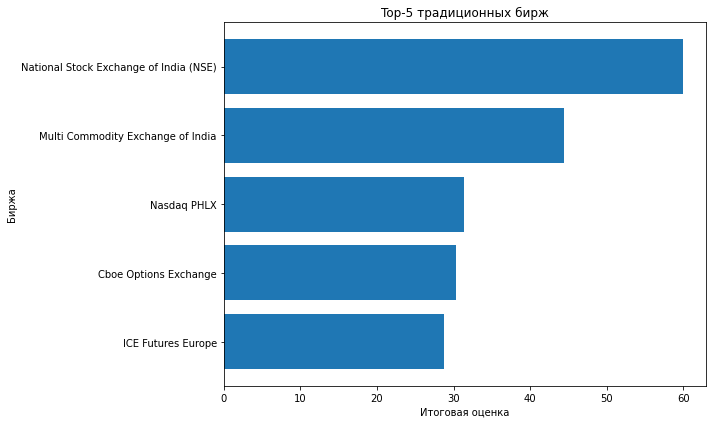

In [13]:
plt.figure(figsize=(10, 6))

plt.barh(
    traditional_top5["Exchange name"][::-1],
    traditional_top5["Final Score"][::-1]
)

plt.xlabel("Итоговая оценка")
plt.ylabel("Биржа")
plt.title("Top-5 традиционных бирж")

plt.tight_layout()
plt.show()

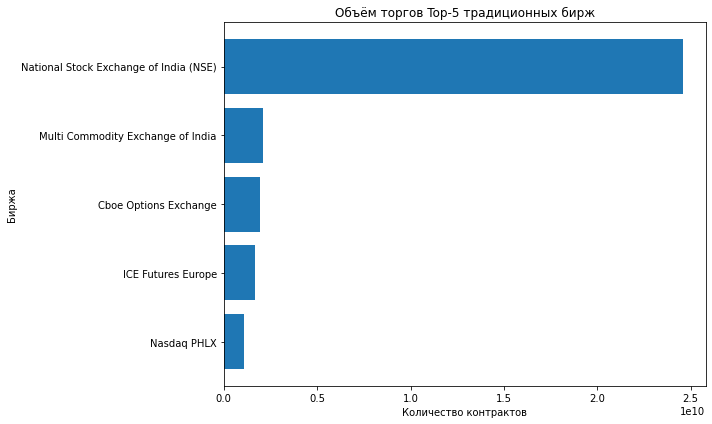

In [14]:
top5_names = traditional_top5["Exchange name"]

traditional_top5_data = traditional_score[
    traditional_score["Exchange name"].isin(top5_names)
].sort_values("YTD Trading Volume")

plt.figure(figsize=(10, 6))

plt.barh(
    traditional_top5_data["Exchange name"],
    traditional_top5_data["YTD Trading Volume"]
)

plt.xlabel("Количество контрактов")
plt.ylabel("Биржа")
plt.title("Объём торгов Top-5 традиционных бирж")

plt.tight_layout()
plt.show()

## 4. Анализ криптовалютных бирж

Для оценки криптовалютных бирж используются следующие показатели:

- **Total Trading Volume (USD)** — общий объем торгов;

- **Trust Score** — оценка надежности биржи;

- **Average Bid-Ask Spread (%)** — средний спред;

- **Base Maker Fee (%)** — базовая комиссия maker;

- **Base Taker Fee (%)** — базовая комиссия taker;

- **Number of Trading Instruments** — количество торговых инструментов.

Показатели имеют разные единицы измерения, поэтому перед расчетом итоговой оценки они приводятся к сопоставимой шкале.

In [15]:
crypto_clean = crypto.copy()
crypto_clean.dtypes

Exchange name                     object
Total Trading Volume (USD)         int64
Volume Unit                       object
Trust Score                      float64
Average Bid-Ask Spread (%)       float64
Base Maker Fee (%)               float64
Base Taker Fee (%)               float64
Number of Trading Instruments      int64
dtype: object

In [16]:
crypto_clean["Trust Score"] = pd.to_numeric(
    crypto_clean["Trust Score"],
    errors="coerce"
)

crypto_clean.isna().sum()

Exchange name                    0
Total Trading Volume (USD)       0
Volume Unit                      0
Trust Score                      4
Average Bid-Ask Spread (%)       0
Base Maker Fee (%)               0
Base Taker Fee (%)               0
Number of Trading Instruments    0
dtype: int64

### 4.1 Методология оценки

Для формирования итогового рейтинга используются четыре показателя:

- **Total Trading Volume** — 35%;
- **Trust Score** — 30%;
- **Base Taker Fee** — 20%;
- **Number of Trading Instruments** — 15%.

Объем торгов, Trust Score и количество инструментов оцениваются по принципу «чем больше, тем лучше».

Для торговой комиссии применяется обратный принцип: более низкая комиссия получает более высокую оценку.

Средний Bid-Ask Spread анализируется отдельно и не включается в итоговый рейтинг, поскольку доступные значения для разных бирж могут относиться к различным сегментам рынка.

Если Trust Score отсутствует, итоговая оценка рассчитывается по доступным показателям с пропорциональным перераспределением весов.

In [17]:
crypto_score = crypto_clean.copy()

crypto_score["Volume_norm"] = (
    crypto_score["Total Trading Volume (USD)"] /
    crypto_score["Total Trading Volume (USD)"].max()
)

crypto_score["Trust_norm"] = (
    crypto_score["Trust Score"] / 10
)

crypto_score["Fee_norm"] = (
    1 - crypto_score["Base Taker Fee (%)"] /
    crypto_score["Base Taker Fee (%)"].max()
)

crypto_score["Instruments_norm"] = (
    crypto_score["Number of Trading Instruments"] /
    crypto_score["Number of Trading Instruments"].max()
)

crypto_score[
    [
        "Exchange name",
        "Volume_norm",
        "Trust_norm",
        "Fee_norm",
        "Instruments_norm"
    ]
]

,Exchange name,Volume_norm,Trust_norm,Fee_norm,Instruments_norm
0,Binance,1.000000,1.0,0.8,0.440930
1,Bybit,0.269438,0.9,0.8,0.237573
2,OKX,0.420884,1.0,0.8,0.356359
3,MEXC,0.235077,0.9,0.8,1.000000
4,Gate,0.235772,1.0,0.8,0.781472
5,Hyperliquid,0.140718,NaN,0.8,0.073919
6,HTX,0.054508,0.6,0.6,0.185926
7,Bitget,0.168332,1.0,0.8,0.193673
8,Coinbase,0.039919,1.0,0.2,0.144932
9,Crypto.com,0.034415,0.9,0.0,0.170110


In [18]:
weights = {
    "Volume_norm": 0.35,
    "Trust_norm": 0.30,
    "Fee_norm": 0.20,
    "Instruments_norm": 0.15
}

def calculate_crypto_score(row):
    available = {
        "Volume_norm": row["Volume_norm"],
        "Trust_norm": row["Trust_norm"],
        "Fee_norm": row["Fee_norm"],
        "Instruments_norm": row["Instruments_norm"]
    }

    available = {
        key: value
        for key, value in available.items()
        if pd.notna(value)
    }

    total_weight = sum(weights[key] for key in available)

    score = sum(
        available[key] * weights[key]
        for key in available
    ) / total_weight

    return score * 100

crypto_score["Final Score"] = crypto_score.apply(
    calculate_crypto_score,
    axis=1
)

crypto_ranking = crypto_score.sort_values(
    "Final Score",
    ascending=False
).reset_index(drop=True)

crypto_ranking[
    [
        "Exchange name",
        "Volume_norm",
        "Trust_norm",
        "Fee_norm",
        "Instruments_norm",
        "Final Score"
    ]
]

,Exchange name,Volume_norm,Trust_norm,Fee_norm,Instruments_norm,Final Score
0,Binance,1.000000,1.0,0.8,0.440930,87.613944
1,MEXC,0.235077,0.9,0.8,1.000000,66.227703
2,OKX,0.420884,1.0,0.8,0.356359,66.076320
3,Gate,0.235772,1.0,0.8,0.781472,65.974096
4,Bybit,0.269438,0.9,0.8,0.237573,55.993932
5,Bitget,0.168332,1.0,0.8,0.193673,54.796726
6,BingX,0.008151,0.9,0.8,0.238864,46.868257
7,Kraken,0.015720,1.0,0.2,0.475145,41.677387
8,Bitfinex,0.005269,0.8,0.6,0.112008,37.864542
9,Coinbase,0.039919,1.0,0.2,0.144932,37.571140


In [19]:
crypto_top5 = crypto_ranking[
    ["Exchange name", "Final Score"]
].head(5)

crypto_top5

,Exchange name,Final Score
0,Binance,87.613944
1,MEXC,66.227703
2,OKX,66.076320
3,Gate,65.974096
4,Bybit,55.993932


### 4.2 Что определило места в количественном TOP-5

На первой диаграмме итоговый балл разделён на вклады четырёх критериев. Так видно не только место биржи, но и за счёт чего оно получено. Например, второе место MEXC в основном объясняется максимальным показателем количества инструментов и высоким баллом за низкую комиссию.

Это рейтинг по выбранной формуле. Ниже он отдельно сопоставляется с моим экспертным итогом исследования, в котором учтены факторы, не вошедшие в Final Score.

In [ ]:
crypto_top5_components = crypto_ranking.head(5).copy()
crypto_top5_components["Объём торгов"] = crypto_top5_components["Volume_norm"] * weights["Volume_norm"] * 100
crypto_top5_components["Trust Score"] = crypto_top5_components["Trust_norm"] * weights["Trust_norm"] * 100
crypto_top5_components["Комиссия"] = crypto_top5_components["Fee_norm"] * weights["Fee_norm"] * 100
crypto_top5_components["Количество инструментов"] = crypto_top5_components["Instruments_norm"] * weights["Instruments_norm"] * 100

component_columns = ["Объём торгов", "Trust Score", "Комиссия", "Количество инструментов"]
axis = crypto_top5_components.set_index("Exchange name")[component_columns].plot(
    kind="barh", stacked=True, figsize=(11, 6), width=0.72
)
axis.invert_yaxis()
axis.set_title("Из чего складывается количественная оценка TOP-5")
axis.set_xlabel("Вклад критерия в Final Score, баллы")
axis.set_ylabel("")
axis.grid(axis="x", alpha=0.25)
axis.legend(loc="lower right", frameon=False)

for row_number, total in enumerate(crypto_top5_components["Final Score"]):
    axis.text(total + 0.7, row_number, f"{total:.2f}", va="center")

plt.tight_layout()
plt.show()

In [ ]:
quantitative_order = ["Binance", "MEXC", "OKX", "Gate", "Bybit", "Bitget"]
expert_order = ["Binance", "OKX", "Bybit", "Bitget", "Gate", "MEXC"]
quantitative_position = {name: position for position, name in enumerate(quantitative_order, 1)}
expert_position = {name: position for position, name in enumerate(expert_order, 1)}

fig, axis = plt.subplots(figsize=(10, 6))
for exchange in quantitative_order:
    left = quantitative_position[exchange]
    right = expert_position[exchange]
    axis.plot([0, 1], [left, right], marker="o", linewidth=1.8)
    axis.text(-0.03, left, exchange, ha="right", va="center")
    axis.text(1.03, right, exchange, ha="left", va="center")

axis.set_xlim(-0.35, 1.35)
axis.set_ylim(6.5, 0.5)
axis.set_xticks([0, 1], ["Количественная модель", "Мой экспертный итог"])
axis.set_yticks(range(1, 7))
axis.set_ylabel("Место")
axis.set_title("Как изменился TOP после экспертной проверки")
axis.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# 6. Итоговые результаты

В рамках исследования был проведён сравнительный анализ традиционных и криптовалютных бирж на основе выбранных количественных и качественных показателей.

## Традиционные биржи

По результатам итоговой оценки в Top-5 вошли:

1. National Stock Exchange of India (NSE)
2. Multi Commodity Exchange of India (MCX)
3. Nasdaq PHLX
4. Cboe Options Exchange
5. ICE Futures Europe

Рейтинг сформирован на основе доступных показателей торговой активности, динамики объёмов, количества инструментов и экспертной оценки.

## Криптовалютные биржи

По результатам количественной модели в Top-5 вошли:

1. Binance
2. MEXC
3. OKX
4. Gate
5. Bybit

Этот порядок получен по формуле, в которой учитывались объём торгов, Trust Score, торговые комиссии и количество доступных инструментов. Мой итог после экспертной проверки отличается: Binance, OKX, Bybit, Bitget и Gate. Это моя независимая оценка, а не второй математически рассчитанный рейтинг.

## Основной вывод

Количественная модель полезна тем, что её результат можно воспроизвести: при тех же данных и весах получится тот же Final Score. Но она отвечает только за показатели, включённые в формулу. Экспертный итог отвечает на более широкий вопрос и учитывает специализацию площадок, раскрытие резервов и механизмы защиты пользователей. Поэтому эти два результата показаны отдельно.